In [104]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
# df = pd.read_csv("..data/resume_dataset.csv")

In [156]:
df = pd.read_csv("../data/resume_dataset.csv")

In [157]:
df.head()

,resume_str,category
0,Summary\n\nJESSICA CLAIRE\n\nMontgomery Street...,Accountant
1,Julie A. McFederal\n\n11111 Shaw Avenue; Fresn...,Accountant
2,"Tammy Jones 4759 ale Lane, Plano, Texas, Unite...",Accountant
3,Profile\n\n¢€\nCs\n\nHoward Jones and analytic...,Accountant
4,Miley Nguyen\n\nTax Accountant who achieved re...,Accountant


In [107]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'[^a-zA-Z ]', ' ', text)  # remove symbols
    text = re.sub(r'\s+', ' ', text)         # remove extra spaces
    return text

df['cleaned'] = df['resume_str'].apply(clean_text)

In [108]:
df.head()

,resume_str,category,cleaned
0,Summary\n\nJESSICA CLAIRE\n\nMontgomery Street...,Accountant,summary jessica claire montgomery street san f...
1,Julie A. McFederal\n\n11111 Shaw Avenue; Fresn...,Accountant,julie a mcfederal shaw avenue fresno ca home m...
2,"Tammy Jones 4759 ale Lane, Plano, Texas, Unite...",Accountant,tammy jones ale lane plano texas united states...
3,Profile\n\n¢€\nCs\n\nHoward Jones and analytic...,Accountant,profile cs howard jones and analytical review ...
4,Miley Nguyen\n\nTax Accountant who achieved re...,Accountant,miley nguyen tax accountant who achieved resul...


In [109]:
df = df[df['cleaned'].str.strip()!=""]
df.head()

,resume_str,category,cleaned
0,Summary\n\nJESSICA CLAIRE\n\nMontgomery Street...,Accountant,summary jessica claire montgomery street san f...
1,Julie A. McFederal\n\n11111 Shaw Avenue; Fresn...,Accountant,julie a mcfederal shaw avenue fresno ca home m...
2,"Tammy Jones 4759 ale Lane, Plano, Texas, Unite...",Accountant,tammy jones ale lane plano texas united states...
3,Profile\n\n¢€\nCs\n\nHoward Jones and analytic...,Accountant,profile cs howard jones and analytical review ...
4,Miley Nguyen\n\nTax Accountant who achieved re...,Accountant,miley nguyen tax accountant who achieved resul...


In [117]:
X = df['cleaned']
y = df['category']

In [118]:
print(X)

0       summary jessica claire montgomery street san f...
1       julie a mcfederal shaw avenue fresno ca home m...
2       tammy jones ale lane plano texas united states...
3       profile cs howard jones and analytical review ...
4       miley nguyen tax accountant who achieved resul...
                              ...                        
6937    first last web developer web developer with fi...
6938    web designer resume creative web designer with...
6939    experience education mona hintz beer union chi...
6940    jonathan line web designer phone linkedin link...
6941    stephanie smith senior web developer innovativ...
Name: cleaned, Length: 6942, dtype: object


In [126]:
vectorizer = TfidfVectorizer(stop_words='english',max_features=5000,ngram_range=(1,2))

In [127]:
x_vec = vectorizer.fit_transform(X)

In [128]:
X_train,X_test,y_train,y_test = train_test_split(x_vec,y,test_size=0.2,random_state=42)

In [129]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [137]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [141]:
from sklearn.svm import LinearSVC
model = LinearSVC()
model.fit(X_train,y_train)

LinearSVC()

In [142]:
y_pred = model.predict(X_test)

In [143]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8034557235421166


In [144]:
sample = ["I have experience in Java Spring Boot microservices"]

sample_vec = vectorizer.transform(sample)
print(model.predict(sample_vec))

['Java Developer']


In [145]:
print(df['category'].value_counts())

category
Accountant                        350
Advocate                          340
Human Resources                   299
Management                        268
Agricultural                      268
Banking                           262
Data Science                      260
Aviation                          251
Database                          249
Designer                          236
Consultant                        219
DevOps Engineer                   213
SAP Developer                     193
Testing                           185
ETL Developer                     170
Civil Engineer                    149
Architect                         144
React Developer                   138
Sales                             137
Education                         136
Business Analyst                  133
SQL                               128
Information Technology            128
Python Developer                  126
Apparel                           120
Electrical Engineering            115
Aut

In [146]:
for i in range(10):
    print("Actual:", y_test.iloc[i])
    print("Pred:", y_pred[i])

Actual: ETL Developer
Pred: SQL
Actual: Testing
Pred: Advocate
Actual: Testing
Pred: Testing
Actual: SQL
Pred: SQL
Actual: Testing
Pred: Testing
Actual: SQL
Pred: SQL
Actual: Accountant
Pred: Accountant
Actual: Civil Engineer
Pred: Civil Engineer
Actual: Food
Pred: Food
Actual: Designer
Pred: Design


In [147]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Liner SVC": LinearSVC(),
    "Logistic Regression": LogisticRegression()
}

In [148]:
result = {}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    result[name] = acc
print(result)

{'Naive Bayes': 0.6184305255579554, 'Liner SVC': 0.8034557235421166, 'Logistic Regression': 0.7717782577393808}


In [149]:
import matplotlib.pyplot as plt

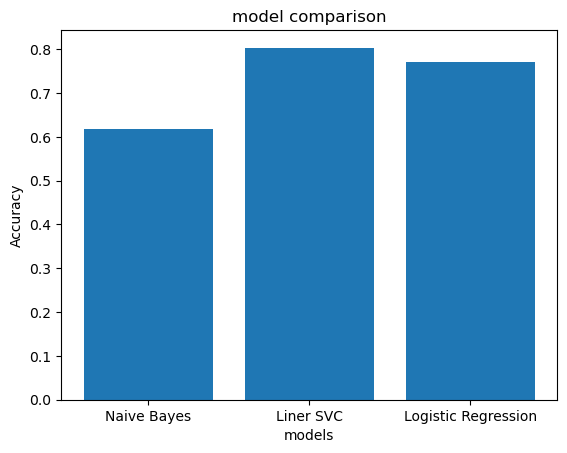

In [154]:
names = list(result.keys())
scores = list(result.values())

plt.bar(names,scores)
plt.xlabel("models")
plt.ylabel("Accuracy")
plt.title("model comparison")
plt.show()

In [155]:
import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/resume-dataset/resume_dataset.csv")

# Preview data
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/resume-dataset/resume_dataset.csv'